# Constant-Thickness STW under Distributed Tip Load

This notebook documents the Nastran linear buckling (SOL 105) and nonlinear
(SOL 106) analyses of the Simple Transonic Wing (STW) wingbox with uniform
thickness under a distributed tip load, and compares the results against a
corresponding CUF equilibrium curve.

**Analysis files:**
- `sol_105_constant_thickness_distributed_tip_load.*`
- `sol_106_constant_thickness_distributed_tip_load.*` (four convergence variants)
- `equ_curve_spessore_costante.dat` (CUF reference)

***

Import shared utilities and define case-specific constants.

In [1]:
# Import system and OS modules to manage the Python path and file system interactions
import sys
import os

# When Jupyter's CWD is the notebook's own directory (stw-nastran-vs-cuf/),
# the project's `resources` package is not on sys.path.  Detect this and add
# the parent directory (notebooks/) automatically.
_parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(_parent, "resources")) and _parent not in sys.path:
    sys.path.insert(0, _parent)

# Import third-party libraries and functions
import numpy as np
from pyNastran.op2.op2 import read_op2
import openmdao.api as om

# Import custom utilities
from resources import pynastran_utils
from resources import plot_utils
from resources.STW import nastran_vs_cuf_utils
from resources.STW import stw_utils
from resources.STW import wingGeometry

# ── Case-specific constants ───────────────────────────────────────────────────
ANALYSIS_DIR = nastran_vs_cuf_utils.ANALYSIS_DIRECTORY_PATH
FIRST_SUBCASE_ID = nastran_vs_cuf_utils.FIRST_SUBCASE_ID
SECOND_SUBCASE_ID = nastran_vs_cuf_utils.SECOND_SUBCASE_ID
METHOD_SET_ID = nastran_vs_cuf_utils.METHOD_SET_ID
INPUT_NAME_SUFFIX = "constant_thickness_distributed_tip_load"

# Applied load parameters
TOTAL_FORCE = 1.0   # reference unit load [N] – buckling load factor scales this
FORCE_RATIO = 0.25  # F(front spar) / F(rear spar)
FORCE_SET_ID = 1    # SID of the FORCE cards

# SOL 105 amplification factor for mode-shape visualisation
AMPLIFICATION_FACTOR = 2.5

Configure default plotting settings.

In [2]:
import matplotlib.pyplot as plt

nastran_vs_cuf_utils.configure_plotting()

COLORS = nastran_vs_cuf_utils.COLORS
MARKERS = nastran_vs_cuf_utils.MARKERS
GLASS_CEILING_COLOR = nastran_vs_cuf_utils.GLASS_CEILING_COLOR
TEXTWIDTH_INCHES = nastran_vs_cuf_utils.TEXTWIDTH_INCHES
FIG_HEIGHT_INCHES = nastran_vs_cuf_utils.FIG_HEIGHT_INCHES

Create STW structural model with the same mesh as the SciTech 2025 paper.

In [3]:
target_length = 53e-3  # target element edge length [m]
stw_bdf, stw_layout = wingGeometry.create_base_bdf(target_length)
print(stw_bdf.get_bdf_stats())

pyGeo Initialization Type is: iges
Found 6 surfaces in Iges File.
Projecting Super Nodes...
Projecting All Nodes...
Setting up Ribs...
Setting up Spars...
Setting up Skins and Stringers...
Setting up Spar Bars
Setting up Rib Bars
Computing Topology and Numbering...
Unique Nodes: 45483
Total Nodes: 65046
Writing .bdf File...
---BDF Statistics---
SOL 103

bdf.spcs[1]: 354
  SPC:     354

bdf.params: 0
  PARAM    : 1

bdf.nodes: 45483
  GRID     : 45483

bdf.elements: 46432
  CQUAD4   : 46432

bdf.properties: 0
  PSHELL   : 1110

bdf.materials: 0
  MAT1     : 1




subcase=0 already exists...skipping


## Distributed Tip Load

Apply a linearly distributed upward force at the wingbox tip. The total reference force is 1 N split equally between the upper and lower skin nodes; the distribution is linear such that the nodal force on the front spar is 1/4 the nodal force on the rear spar (`FORCE_RATIO = 0.25`), inducing a twist down at the tip.

In [4]:
# Create deep copy of the base BDF for load application
distributed_tip_load_bdf = stw_bdf.__deepcopy__({})

# Apply linearly distributed tip load
stw_utils.apply_distributed_tip_load(
    layout=stw_layout,
    bdf=distributed_tip_load_bdf,
    ratio=FORCE_RATIO,
    total_force=TOTAL_FORCE,
    set_id=FORCE_SET_ID,
)

# Create the static-load subcase
pynastran_utils.create_static_load_subcase(
    bdf=distributed_tip_load_bdf,
    load_set_id=FORCE_SET_ID,
    subcase_id=FIRST_SUBCASE_ID,
)

## Linear Buckling Analysis (SOL 105)

### Set Up

In [5]:
# Create deep copy of the load BDF for SOL 105
sol_105_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up linear buckling solution with eigenvalue method set
pynastran_utils.set_up_sol_105(
    bdf=sol_105_bdf,
    static_load_set_id=FORCE_SET_ID,
    method_set_id=METHOD_SET_ID,
)

# Request element stress output for post-processing
sol_105_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

subcase=1 already exists...skipping


### Run

In [6]:
# Define OpenMDAO linear buckling problem
linear_problem = om.Problem(name="linear_distributed_tip_load")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=INPUT_NAME_SUFFIX,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_105_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
linear_problem.setup()
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_105_constant_thickness_distributed_tip_load.bdf completed
Wall time: 39.0 s


### Results

Read the op2 file, print the linear buckling load factor, and plot the critical
buckling mode shape.

Linear buckling load: 133267.19 N


/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


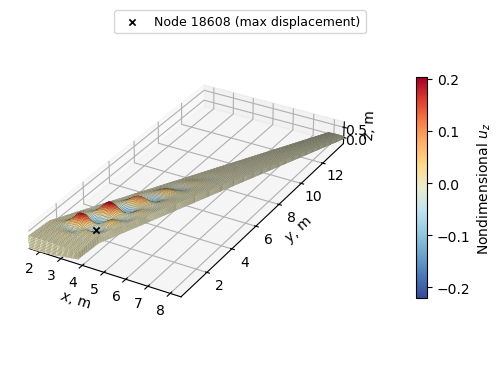


Max-displacement node ID : 18608
Node coordinates (x, y, z) [m]: [3.02882401 2.48676316 0.27278431]


In [7]:
%matplotlib widget

# Read op2 file
sol_105_op2_path = os.path.join(ANALYSIS_DIR, f"sol_105_{INPUT_NAME_SUFFIX}.op2")
sol_105_op2 = read_op2(sol_105_op2_path, load_geometry=True, debug=None)

# Extract and print linear buckling load
# Note that the eigenvalues of SOL 105 are buckling load factors, that is to say
# P_buckling/P_applied. Since we applied a reference load of 1 N, the buckling load
# factor is numerically equal to the buckling load in Newtons.
linear_buckling_load = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Linear buckling load: {linear_buckling_load:.2f} N")

# Plot critical buckling mode shape
_, ax, _ = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=AMPLIFICATION_FACTOR,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)

# Mark and record the node with maximum out-of-plane displacement
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_105_op2, displacement_amplification_factor=AMPLIFICATION_FACTOR
)

# Add plot legend, adjust 3D plot settings, and display
ax.legend()
nastran_vs_cuf_utils.adjust_3d_plot(ax)
plt.show()

# Print the ID and coordinates of the node with maximum out-of-plane displacement
print(f"\nMax-displacement node ID : {max_disp_node_id}")
print(f"Node coordinates (x, y, z) [m]: {sol_105_op2.nodes[max_disp_node_id].xyz}")

## Nonlinear Analyses (SOL 106)

Several arc-length analyses are run, each using different NLPARM convergence settings. All analyses are executed with an applied load of 1.5 times the linear buckling load, which is expected to induce evident buckling deformation.

In [8]:
# Initialize data structures for storing SOL 106 results
sol_106_keys = []    # will store keys for the SOL 106 cases
sol_106_op2s = {}    # will store {key: OP2 object}
sol_106_labels = {}  # will store {key: label} for plotting (legend)

# Define the applied load for the SOL 106 cases as 150% of the linear buckling load
applied_load = linear_buckling_load * 1.5

### EPSP = EPSU = 5e-6

This is the case with the tightest convergence settings. The table below summarizes the parameters of the NLPARM and NLPCI cards for this case.

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | PU |
| EPSU | $5 \cdot 10^{-6}$ |
| EPSP | $5 \cdot 10^{-6}$ |
| DESITER | 4 |
| MXINC | 600 |

In [9]:
# Define key and label for the SOL 106 case with eps_p = eps_u = 5e-6
nastran_key = "epsp_5e-6_epsu_5e-6"
sol_106_keys.append(nastran_key)
sol_106_labels[nastran_key] = r"$\varepsilon_p = \varepsilon_u = 5 \cdot 10^{-6}$"

# Define NLPARM and NLPCI parameters
conv = "PU"
epsp = 5e-6
epsu = 5e-6
mxinc = 600

#### Set Up and Run

In [10]:
# Build the SOL 106 BDF using the shared helper
sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,  # scale factor applied to the reference unit load
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    mxinc=mxinc,
)

# Create OpenMDAO nonlinear problem
nonlinear_problem = om.Problem(name=f"nonlinear_distributed_tip_load_{nastran_key}")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=f"{INPUT_NAME_SUFFIX}_{nastran_key}",
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

# Read op2 file
op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{nastran_key}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_path, load_geometry=True, debug=None)

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_constant_thickness_distributed_tip_load_epsp_5e-6_epsu_5e-6.bdf completed
Wall time: 112716.0 s


#### Comparison with CUF

Read load and displacement histories from Nastran analysis and from the CUF equilibrium curve file.

In [11]:
# Find tip nodes (used to compute mean tip deflection)
tip_nodes_ids, _ = stw_utils.find_tip_nodes(stw_layout, sol_106_op2s[nastran_key])

# Read Nastran load and displacement histories for each variant
nastran_loads = {}
nastran_disps = {}

_, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2s[nastran_key], node_ids=list(tip_nodes_ids) + [max_disp_node_id]
)
nastran_loads[nastran_key] = loads
nastran_disps[nastran_key] = disps

# Read CUF equilibrium curve
cuf_filepath = os.path.join(ANALYSIS_DIR, "equ_curve_constant_thickness.dat")
cuf_data = nastran_vs_cuf_utils.read_cuf_data(cuf_filepath, max_disp_node_id=max_disp_node_id)
print(f"CUF node ID from file: {cuf_data['node_id']}")
print(f"CUF max applied load : {cuf_data['P[N]'].max():.2f} N")

CUF node ID from file: 18608
CUF max applied load : 400558.60 N


Plot tip displacement vs applied load.

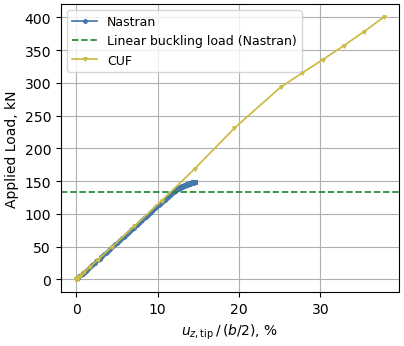

In [12]:
# Create figure and axis for tip displacement vs applied load plot
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.65, FIG_HEIGHT_INCHES))

# Plot Nastran nonlinear analysis
tip_disp = stw_utils.calculate_tip_deflection(
    nastran_disps[nastran_key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
    nastran_disps[nastran_key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
)
ax.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Linear buckling load reference line
ax.axhline(
    y=linear_buckling_load/1e3,
    linestyle="--",
    color=GLASS_CEILING_COLOR,
    label="Linear buckling load (Nastran)",
)

# CUF equilibrium curve
ax.plot(
    cuf_data["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Finalize plot settings and display
ax.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax.set_ylabel("Applied Load, kN")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

Plot the out-of-plane ($z$) and in-plane ($y$) displacements at the node that shows the largest displacement in the linear buckling mode.

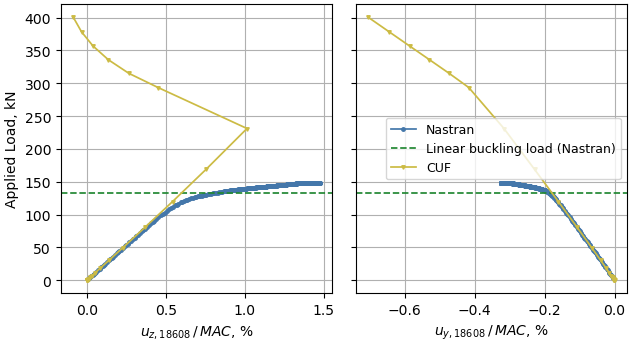

In [13]:
# Create figure and axes for local displacement vs applied load plots
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, figsize=(TEXTWIDTH_INCHES, FIG_HEIGHT_INCHES)
)

# Extract local displacements at the node with maximum out-of-plane displacement
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Plot Nastran nonlinear analysis results for out-of-plane (u_z) and in-plane (u_y) displacements
ax1.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax2.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference lines
for ax in (ax1, ax2):
    ax.axhline(
        y=linear_buckling_load/1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load (Nastran)",
    )

# Plot CUF local displacements
cuf_label = "CUF"
ax1.plot(
    cuf_data[f"node {max_disp_node_id} w[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax2.plot(
    cuf_data[f"node {max_disp_node_id} v[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Finalize plot settings and display
ax1.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax2.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax1.set_ylabel("Applied Load, kN")
ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
ax2.legend()
plt.show()

#### Comparison with CUF arc_opt = 3, toll = 1e-4

Read load and displacement histories from the CUF equilibrium curve file.

In [14]:
# Read CUF equilibrium curve
cuf_filepath = os.path.join(ANALYSIS_DIR, "equ_curve_arcopt_3_tol_10-4.dat")
cuf_data = nastran_vs_cuf_utils.read_cuf_data(cuf_filepath, max_disp_node_id=max_disp_node_id)
print(f"CUF node ID from file: {cuf_data['node_id']}")
print(f"CUF max applied load : {cuf_data['P[N]'].max():.2f} N")

CUF node ID from file: 18608
CUF max applied load : 271222.80 N


Plot tip displacement vs applied load.

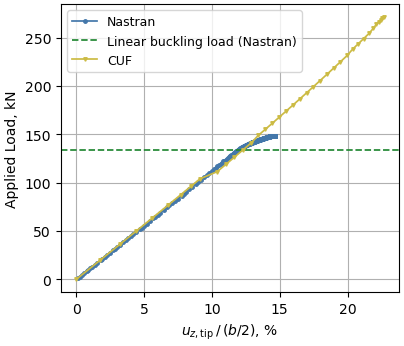

In [15]:
# Create figure and axis for tip displacement vs applied load plot
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.65, FIG_HEIGHT_INCHES))

# Plot Nastran nonlinear analysis
ax.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Linear buckling load reference line
ax.axhline(
    y=linear_buckling_load/1e3,
    linestyle="--",
    color=GLASS_CEILING_COLOR,
    label="Linear buckling load (Nastran)",
)

# CUF equilibrium curve
ax.plot(
    cuf_data["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Finalize plot settings and display
ax.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax.set_ylabel("Applied Load, kN")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

Plot local displacement vs applied load.

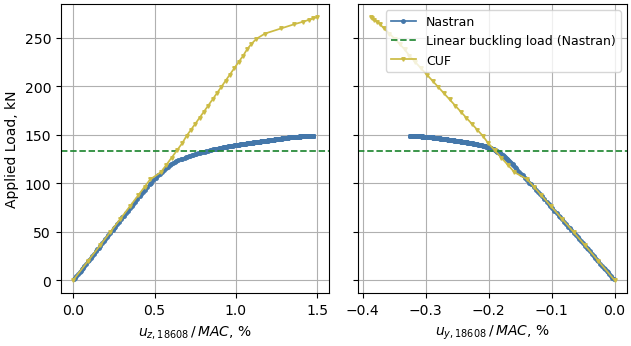

In [16]:
# Create figure and axes for local displacement vs applied load plots
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, figsize=(TEXTWIDTH_INCHES, FIG_HEIGHT_INCHES)
)

# Extract local displacements at the node with maximum out-of-plane displacement
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Plot Nastran nonlinear analysis results for out-of-plane (u_z) and in-plane (u_y) displacements
ax1.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax2.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference lines
for ax in (ax1, ax2):
    ax.axhline(
        y=linear_buckling_load/1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load (Nastran)",
    )

# Plot CUF local displacements
cuf_label = "CUF"
ax1.plot(
    cuf_data[f"node {max_disp_node_id} w[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax2.plot(
    cuf_data[f"node {max_disp_node_id} v[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Finalize plot settings and display
ax1.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax2.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax1.set_ylabel("Applied Load, kN")
ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
ax2.legend()
plt.show()

#### Comparison with CUF 2B4, toll = 1e-4 and toll = 1e-5

In [17]:
# Define keys, filenames, and labels for CUF 2B4 cases with different tolerances
cuf_keys = [
    "tol_1e-4",
    "tol_1e-5",
]
cuf_filenames = [f"equ_curve_constant_thickness_2B4_{cuf_key}.dat" for cuf_key in cuf_keys]
cuf_labels = [
    "CUF, 2B4, tol = $10^{-4}$",
    "CUF, 2B4, tol = $10^{-5}$",
]
cuf_markers = ["v", "^"]
cuf_colors = [COLORS[1], COLORS[2]]

# Read CUF equilibrium curves
cuf_data = {
    cuf_key: nastran_vs_cuf_utils.read_cuf_data(
        os.path.join(ANALYSIS_DIR, filename), max_disp_node_id=max_disp_node_id
    )
    for cuf_key, filename in zip(cuf_keys, cuf_filenames)
}

Plot tip displacement vs applied load.

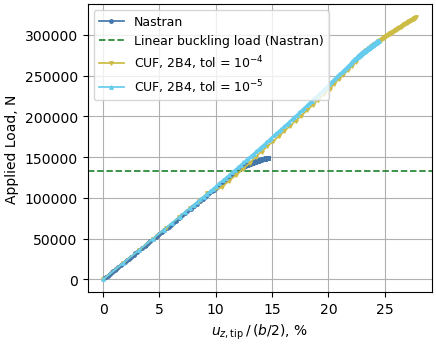

In [ ]:
# Create figure and axis for tip displacement vs applied load plot
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.75, FIG_HEIGHT_INCHES))

# Plot Nastran nonlinear analysis
ax.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2],
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Linear buckling load reference line
ax.axhline(
    y=linear_buckling_load,
    linestyle="--",
    color=GLASS_CEILING_COLOR,
    label="Linear buckling load (Nastran)",
)

# CUF equilibrium curve
for cuf_key, label, marker, color in zip(cuf_keys, cuf_labels, cuf_markers, cuf_colors):    
    ax.plot(
        cuf_data[cuf_key]["w_tip[m]"] / wingGeometry.semiSpan * 100,
        cuf_data[cuf_key]["P[N]"],
        label=label,
        marker=marker,
        color=color,
    )

# Finalize plot settings and display
ax.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax.set_ylabel("Applied Load, N")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

#### Comparison with CUF 3B4, toll = 1e-5

Read load and displacement histories from the CUF equilibrium curve file.

In [19]:
# Read CUF equilibrium curve
cuf_filepath = os.path.join(ANALYSIS_DIR, "equ_curve_constant_thickness_3B4_tol_1e-5.dat")
cuf_data = nastran_vs_cuf_utils.read_cuf_data(cuf_filepath, max_disp_node_id=max_disp_node_id)
print(f"CUF node ID from file: {cuf_data['node_id']}")
print(f"CUF max applied load : {cuf_data['P[N]'].max():.2f} N")

CUF node ID from file: 18608
CUF max applied load : 299176.13 N


Plot tip displacement vs applied load.

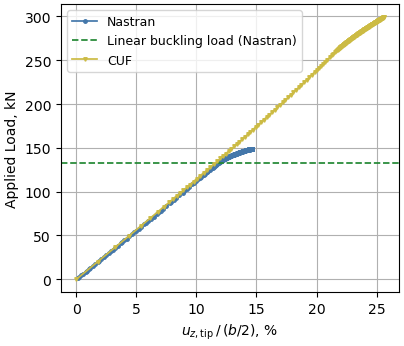

In [20]:
# Create figure and axis for tip displacement vs applied load plot
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.65, FIG_HEIGHT_INCHES))

# Plot Nastran nonlinear analysis
ax.plot(
    tip_disp / wingGeometry.semiSpan * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Linear buckling load reference line
ax.axhline(
    y=linear_buckling_load/1e3,
    linestyle="--",
    color=GLASS_CEILING_COLOR,
    label="Linear buckling load (Nastran)",
)

# CUF equilibrium curve
ax.plot(
    cuf_data["w_tip[m]"] / wingGeometry.semiSpan * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Finalize plot settings and display
ax.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax.set_ylabel("Applied Load, kN")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

Plot local displacement vs applied load.

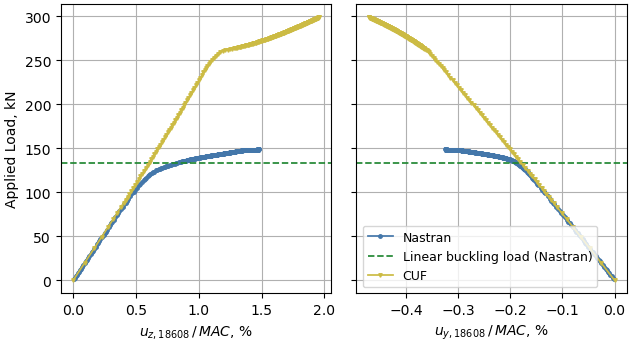

In [21]:
# Create figure and axes for local displacement vs applied load plots
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, figsize=(TEXTWIDTH_INCHES, FIG_HEIGHT_INCHES)
)

# Extract local displacements at the node with maximum out-of-plane displacement
u_z = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
u_y = nastran_disps[nastran_key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]

# Plot Nastran nonlinear analysis results for out-of-plane (u_z) and in-plane (u_y) displacements
ax1.plot(
    u_z / wingGeometry.meanAerodynamicChord * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)
ax2.plot(
    u_y / wingGeometry.meanAerodynamicChord * 100,
    nastran_loads[nastran_key][FIRST_SUBCASE_ID][:, 2]/1e3,
    label="Nastran",
    marker="o",
    color=COLORS[0],
)

# Plot linear buckling reference lines
for ax in (ax1, ax2):
    ax.axhline(
        y=linear_buckling_load/1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load (Nastran)",
    )

# Plot CUF local displacements
cuf_label = "CUF"
ax1.plot(
    cuf_data[f"node {max_disp_node_id} w[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)
ax2.plot(
    cuf_data[f"node {max_disp_node_id} v[m]"] / wingGeometry.meanAerodynamicChord * 100,
    cuf_data["P[N]"]/1e3,
    label="CUF",
    marker="v",
    color=COLORS[1],
)

# Finalize plot settings and display
ax1.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax2.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax1.set_ylabel("Applied Load, kN")
ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
ax2.legend()
plt.show()

### EPSP = EPSU = 1e-5

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | PU |
| EPSU | $10^{-5}$ |
| EPSP | $10^{-5}$ |
| DESITER | 4 |
| MXINC | 500 |

In [ ]:
nastran_key = "epsp_1e-5"
sol_106_keys.append(nastran_key)
sol_106_labels[nastran_key] = r"$\varepsilon_p = \varepsilon_u = 10^{-5}$"

conv = "PU"
epsp = 1e-5
epsu = 1e-5
mxinc = 500

#### Set Up and Run

In [ ]:
sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    mxinc=mxinc,
)

nonlinear_problem = om.Problem(name=f"nonlinear_distributed_tip_load_{nastran_key}")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=f"{INPUT_NAME_SUFFIX}_{nastran_key}",
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_bdf,
    run_flag=False,
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{nastran_key}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_path, load_geometry=True, debug=None)

_, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2s[nastran_key], node_ids=list(tip_nodes_ids) + [max_disp_node_id]
)
nastran_loads[nastran_key] = loads
nastran_disps[nastran_key] = disps

### EPSP = 2.3e-4, EPSU = 1.3e-2 (MAXITER = 40)

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 40 |
| CONV | PU |
| EPSU | $1.3 \cdot 10^{-2}$ |
| EPSP | $2.3 \cdot 10^{-4}$ |
| DESITER | 3 |
| MXINC | 280 |

In [ ]:
nastran_key = "epsp_2p3e-4"
sol_106_keys.append(nastran_key)
sol_106_labels[nastran_key] = (
    r"$\varepsilon_p = 2.3 \cdot 10^{-4}$, $\varepsilon_u = 1.3 \cdot 10^{-2}$ (MAXITER = 40)"
)

conv = "PU"
epsp = 2.3e-4
epsu = 1.3e-2
max_iter = 40
desiter = 3
mxinc = 280

#### Set Up and Run

In [ ]:
sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    max_iter=max_iter,
    desiter=desiter,
    mxinc=mxinc,
)

nonlinear_problem = om.Problem(name=f"nonlinear_distributed_tip_load_{nastran_key}")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=f"{INPUT_NAME_SUFFIX}_{nastran_key}",
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_bdf,
    run_flag=False,
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{nastran_key}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_path, load_geometry=True, debug=None)

_, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2s[nastran_key], node_ids=list(tip_nodes_ids) + [max_disp_node_id]
)
nastran_loads[nastran_key] = loads
nastran_disps[nastran_key] = disps

### EPSW = 1e-5 (CONV = W)

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | W |
| EPSW | $10^{-5}$ |
| DESITER | 4 |
| MXINC | 200 |

In [ ]:
nastran_key = "epsw_1e-5"
sol_106_keys.append(nastran_key)
sol_106_labels[nastran_key] = r"$\varepsilon_w = 10^{-5}$ (CONV = W)"

conv = "W"
epsw = 1e-5
mxinc = 200

#### Set Up and Run

In [ ]:
sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_w=epsw,
    mxinc=mxinc,
)

nonlinear_problem = om.Problem(name=f"nonlinear_distributed_tip_load_{nastran_key}")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=f"{INPUT_NAME_SUFFIX}_{nastran_key}",
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_bdf,
    run_flag=False,
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

op2_path = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{nastran_key}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_path, load_geometry=True, debug=None)

_, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2s[nastran_key], node_ids=list(tip_nodes_ids) + [max_disp_node_id]
)
nastran_loads[nastran_key] = loads
nastran_disps[nastran_key] = disps

## Comparison of Nastran SOL 106 Variants

Now we run three additional SOL 106 analyses with different nonlinear analysis convergence settings.
- *EPSP = EPSU = 1e-5:* this analysis has slightly looser convergence settings than the first case, and it uses in theory the same tolerances employed in the CUF 3B4 case.
- *EPSP = 2.3e-4, EPSU = 1.3e-2 (MAXITER = 40):* this analysis has much looser convergence settings, and it uses the tightest convergence settings that allow the first arc-length step to converge within 3 iterations. MAXITER is increased to 40 to match the value used in the CUF 3B4 case.
- *EPSW = 1e-5 (CONV = W):* this analysis uses the work convergence criterion instead of displacement and load convergence criteria. The tolerance value is chosen in such a way to allow the first arc-length step to converge within 3 iterations.

The four SOL 106 arc-length analyses are summarized in the table below.

| Parameter | EPSP = EPSU = $5 \cdot 10^{-6}$ (baseline) | EPSP = EPSU = $10^{-5}$ | EPSP = $2.3 \cdot 10^{-4}$, EPSU = $1.3 \cdot 10^{-2}$ | EPSW = $10^{-5}$ |
|---|---|---|---|---|
| KMETHOD | ITER | ITER | ITER | ITER |
| KSTEP | −1 | −1 | −1 | −1 |
| MAXITER | 3 | 3 | 40 | 3 |
| CONV | PU | PU | PU | W |
| EPSU | $5×10^{-6}$ | $1×10^{-5}$ | $1.3×10^{-2}$ | — |
| EPSP | $5×10^{-6}$ | $1×10^{-5}$ | $2.3×10^{-4}$ | — |
| EPSW | — | — | — | $1×10^{-6}$ |
| NLPCI type | CRIS | CRIS | CRIS | CRIS |
| DESITER | 4 | 4 | 3 | 4 |
| MXINC | 600 | 500 | 280 | 200 |

Now let's define and run the analyses.

In [ ]:
# Define and run the analyses here

In [ ]:
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.75, FIG_HEIGHT_INCHES))

for i, key in enumerate(sol_106_keys):
    tip_disp_key = stw_utils.calculate_tip_deflection(
        nastran_disps[key][tip_nodes_ids[0]][FIRST_SUBCASE_ID],
        nastran_disps[key][tip_nodes_ids[1]][FIRST_SUBCASE_ID],
    )
    ax.plot(
        tip_disp_key / wingGeometry.semiSpan * 100,
        nastran_loads[key][FIRST_SUBCASE_ID][:, 2] / 1e3,
        label=sol_106_labels[key],
        marker=MARKERS[i % len(MARKERS)],
        color=COLORS[i % len(COLORS)],
    )

ax.axhline(
    y=linear_buckling_load / 1e3,
    linestyle="--",
    color=GLASS_CEILING_COLOR,
    label="Linear buckling load",
)

ax.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax.set_ylabel("Applied Load, kN")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, figsize=(TEXTWIDTH_INCHES, FIG_HEIGHT_INCHES)
)

for i, key in enumerate(sol_106_keys):
    u_z = nastran_disps[key][max_disp_node_id][FIRST_SUBCASE_ID][:, 2]
    u_y = nastran_disps[key][max_disp_node_id][FIRST_SUBCASE_ID][:, 1]
    plot_kwargs = dict(
        label=sol_106_labels[key],
        marker=MARKERS[i % len(MARKERS)],
        color=COLORS[i % len(COLORS)],
    )
    ax1.plot(
        u_z / wingGeometry.meanAerodynamicChord * 100,
        nastran_loads[key][FIRST_SUBCASE_ID][:, 2] / 1e3,
        **plot_kwargs,
    )
    ax2.plot(
        u_y / wingGeometry.meanAerodynamicChord * 100,
        nastran_loads[key][FIRST_SUBCASE_ID][:, 2] / 1e3,
        **plot_kwargs,
    )

for ax in (ax1, ax2):
    ax.axhline(
        y=linear_buckling_load / 1e3,
        linestyle="--",
        color=GLASS_CEILING_COLOR,
        label="Linear buckling load",
    )
    ax.grid(True)

ax1.set_xlabel(f"$u_{{z,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax2.set_xlabel(f"$u_{{y,{max_disp_node_id}}}\\,/\\,MAC$, %")
ax1.set_ylabel("Applied Load, kN")
plt.tight_layout()
ax2.legend()
plt.show()